In [13]:
# Import libraries

import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8) # Adjusts the configuration of the plots we will create

In [214]:
df = pd.read_csv("Downloads/Video+Game+Sales/vgchartz-2024.csv")
df.head()
#to view all the contents of the dataset use: pd.set_option('display.max_rows', None)

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


## The goal of this brief Exploratory Data Analysis is to answer the following questions:

1. Does the critic score and the total sales correlate?
2. Are there any trends with the total game sales overtime?
3. Are there any games that are popular to a region but flop on the others?

In [216]:
# Looking for missing data

for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, pct_missing))

img - 0.0%
title - 0.0%
console - 0.0%
genre - 0.0%
publisher - 0.0%
developer - 0.0002655586103474131%
critic_score - 0.8956823294176456%
total_sales - 0.7044176455886029%
na_sales - 0.8025962259435141%
jp_sales - 0.8949325168707823%
pal_sales - 0.7996750812296926%
other_sales - 0.7636840789802549%
release_date - 0.11014433891527119%
last_update - 0.7207104473881529%


In [218]:
# Check dataypes

df.dtypes

img              object
title            object
console          object
genre            object
publisher        object
developer        object
critic_score    float64
total_sales     float64
na_sales        float64
jp_sales        float64
pal_sales       float64
other_sales     float64
release_date     object
last_update      object
dtype: object

In [220]:
#Round off total sales into 1 decimal place

df['total_sales'] = df['total_sales'].round(1)
df['total_sales']

0        20.3
1        19.4
2        16.2
3        15.9
4        15.1
         ... 
64011     NaN
64012     NaN
64013     NaN
64014     NaN
64015     NaN
Name: total_sales, Length: 64016, dtype: float64

In [234]:
#Create a Year Release column

df['Year_release'] = df['release_date'].astype(str).str[:4]
df

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update,Year_release
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.3,6.37,0.99,9.85,3.12,2013-09-17,NaN,2013
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.4,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03,2014
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.2,8.41,0.47,5.49,1.78,2002-10-28,NaN,2002
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.9,9.06,0.06,5.33,1.42,2013-09-17,NaN,2013
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.1,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64011,/games/boxart/full_2779838AmericaFrontccc.jpg,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-11,2019-01-28,2016
64012,/games/boxart/full_8031506AmericaFrontccc.jpg,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30,2020-05-09,2020
64013,/games/boxart/full_6553045AmericaFrontccc.jpg,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30,2020-05-09,2020
64014,/games/boxart/full_6012940JapanFrontccc.png,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,NaN,NaN,NaN,NaN,NaN,NaN,2019-02-28,2019-02-24,2019


In [222]:
# Sort in terms of Gross

df.sort_values(by=['total_sales'], inplace=False, ascending=False)

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.3,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.4,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.2,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.9,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.1,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64011,/games/boxart/full_2779838AmericaFrontccc.jpg,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-11,2019-01-28
64012,/games/boxart/full_8031506AmericaFrontccc.jpg,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30,2020-05-09
64013,/games/boxart/full_6553045AmericaFrontccc.jpg,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30,2020-05-09
64014,/games/boxart/full_6012940JapanFrontccc.png,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,NaN,NaN,NaN,NaN,NaN,NaN,2019-02-28,2019-02-24


In [371]:
# Drop any duplicates (if any) and also remove img column since this column is not needed

df.drop_duplicates()
del df['img']
df

,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update,Year_release
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.3,6.37,0.99,9.85,3.12,2013-09-17,NaN,2013-01-01
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.4,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03,2014-01-01
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.2,8.41,0.47,5.49,1.78,2002-10-28,NaN,2002-01-01
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.9,9.06,0.06,5.33,1.42,2013-09-17,NaN,2013-01-01
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.1,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14,2015-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64011,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-11,2019-01-28,2016-01-01
64012,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30,2020-05-09,2020-01-01
64013,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30,2020-05-09,2020-01-01
64014,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,NaN,NaN,NaN,NaN,NaN,NaN,2019-02-28,2019-02-24,2019-01-01


## Plot the Total Sales against Critic score using seaborn

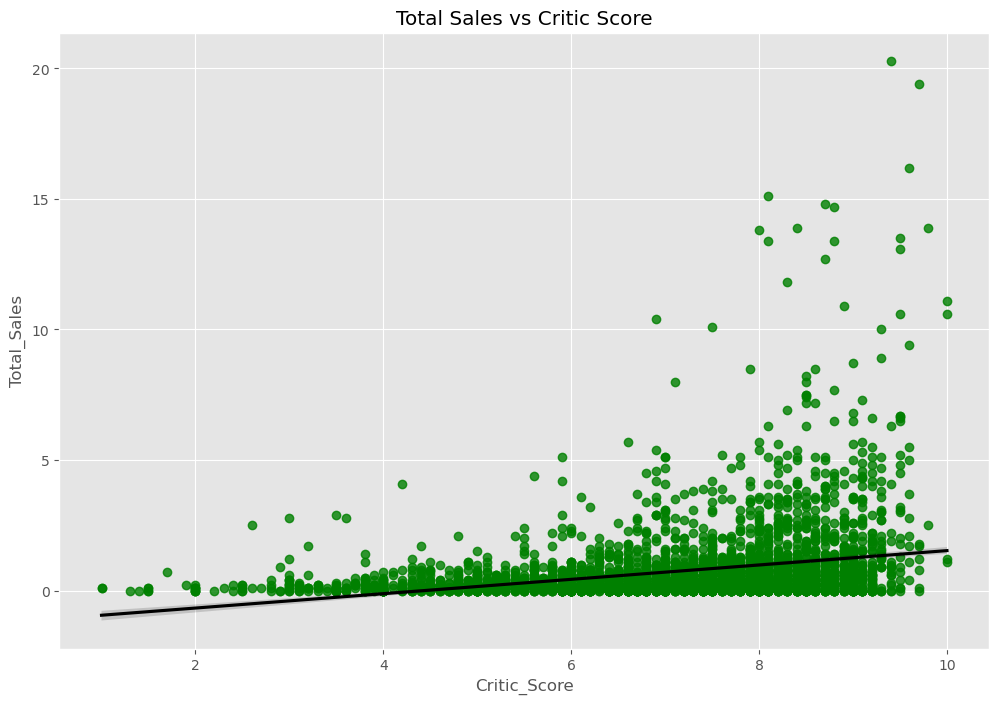

In [373]:

sns.regplot(x='critic_score', y='total_sales', data=df, scatter_kws={"color": "green"}, line_kws={"color": "black"})

plt.title('Total Sales vs Critic Score')
plt.xlabel('Critic_Score')
plt.ylabel('Total_Sales')

plt.show()

## Curious if there's a correlation between Critic Score and Total Sales


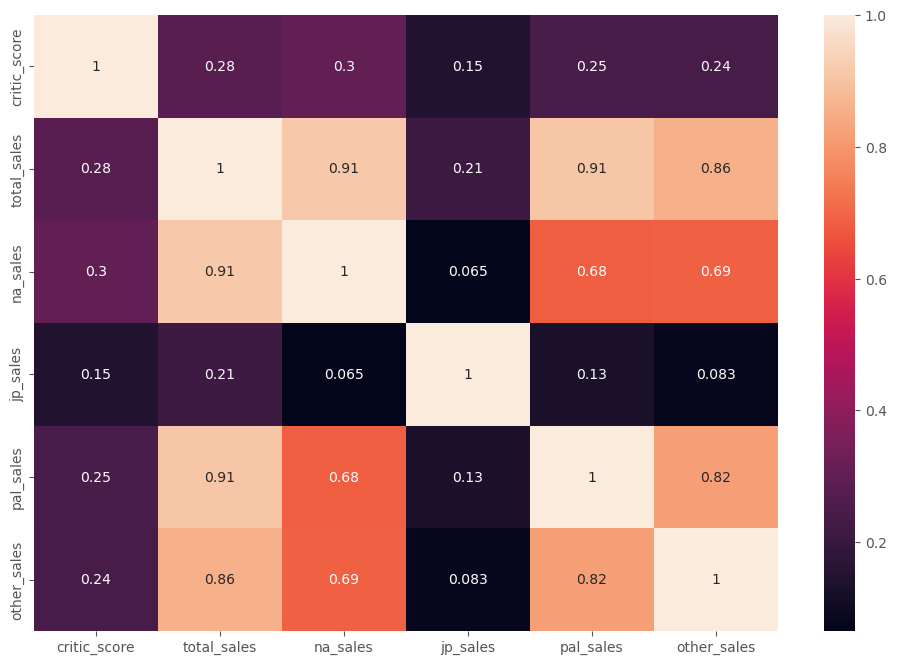

In [375]:
cm = df.corr(method='pearson', numeric_only=True)

sns.heatmap(cm, annot=True)

plt.show()

In [459]:
cmpair = cm.unstack()
cmsort = cmpair.sort_values()
#cmhi = cmsort[((cmsort) > .5) & ((cmsort) < 1)]
cmsort

jp_sales      na_sales        0.065091
na_sales      jp_sales        0.065091
jp_sales      other_sales     0.082653
other_sales   jp_sales        0.082653
pal_sales     jp_sales        0.131796
jp_sales      pal_sales       0.131796
critic_score  jp_sales        0.147448
jp_sales      critic_score    0.147448
total_sales   jp_sales        0.214364
jp_sales      total_sales     0.214364
critic_score  other_sales     0.243847
other_sales   critic_score    0.243847
pal_sales     critic_score    0.246694
critic_score  pal_sales       0.246694
total_sales   critic_score    0.280793
critic_score  total_sales     0.280793
na_sales      critic_score    0.300289
critic_score  na_sales        0.300289
pal_sales     na_sales        0.684517
na_sales      pal_sales       0.684517
              other_sales     0.687512
other_sales   na_sales        0.687512
              pal_sales       0.817030
pal_sales     other_sales     0.817030
total_sales   other_sales     0.858603
other_sales   total_sales

### With this result, this states that the total sales does not correlate with the critic score with a corr value of 0.28

## Next up. Write a time series for total sale of games

In [469]:

#dfg = df.groupby(['Year_release', 'genre'], as_index=False)['total_sales'].sum()
dfg = df.groupby(['Year_release'], as_index=False)['total_sales'].sum()

dfg_10y = dfg[(dfg['Year_release'].dt.year >= 2005) & (dfg['Year_release'].dt.year <= 2023)] #& (dfg['console'] == 'PS4')]


##dfg.nlargest(10, 'total_sales')



<Axes: xlabel='Year_release', ylabel='total_sales'>

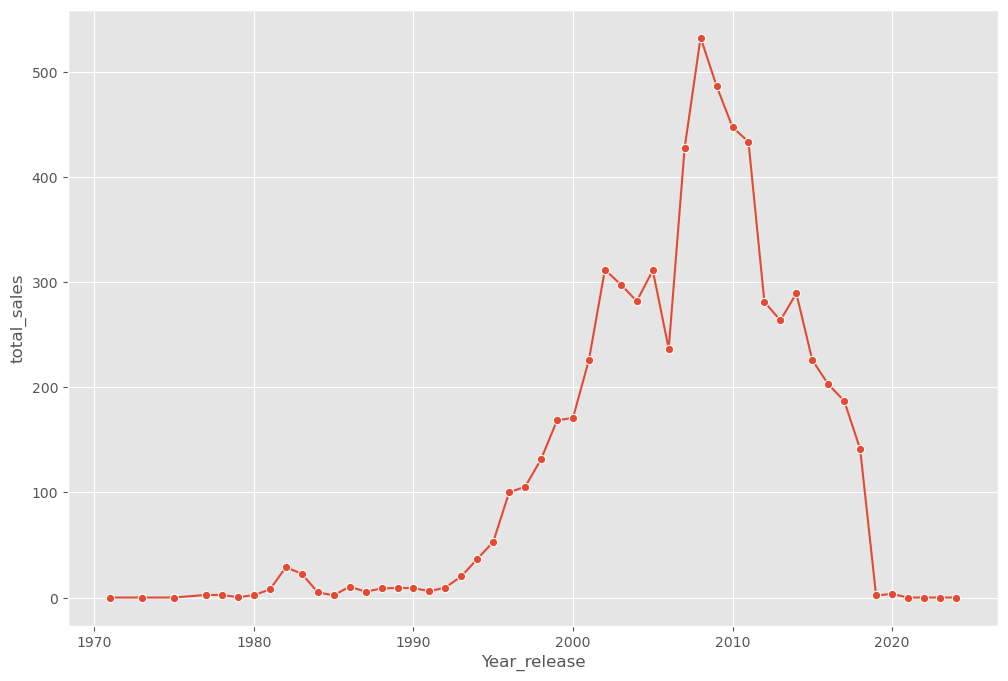

In [471]:
sns.lineplot(x='Year_release', y='total_sales', data = dfg, marker = 'o')

## With the above graph. We could see that that total sale of games peaked at 2008 and then fell down hard at 2020.

### I'm curious on which top 10 games sold the most in 2018

<Axes: xlabel='total_sales', ylabel='title'>

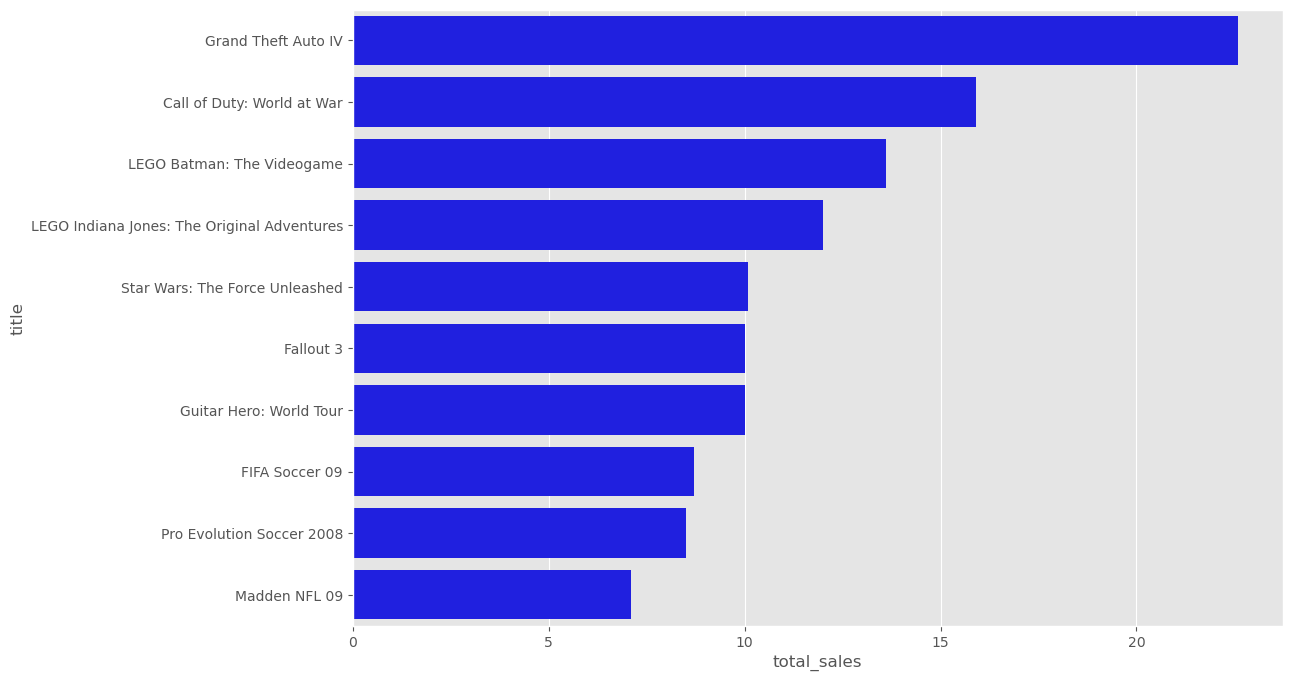

In [483]:
df2 = df[df['Year_release'] == '2008']

agg_sum = df2.groupby('title')['total_sales'].sum().reset_index()

df_top5 = agg_sum.nlargest(10, 'total_sales')

sns.barplot(x='total_sales', y='title', data=df_top5, color = 'blue')

## Since the console that I have was PS4, I'm curious on which top 10 PS4 games sold the most globally

<Axes: xlabel='total_sales', ylabel='title'>

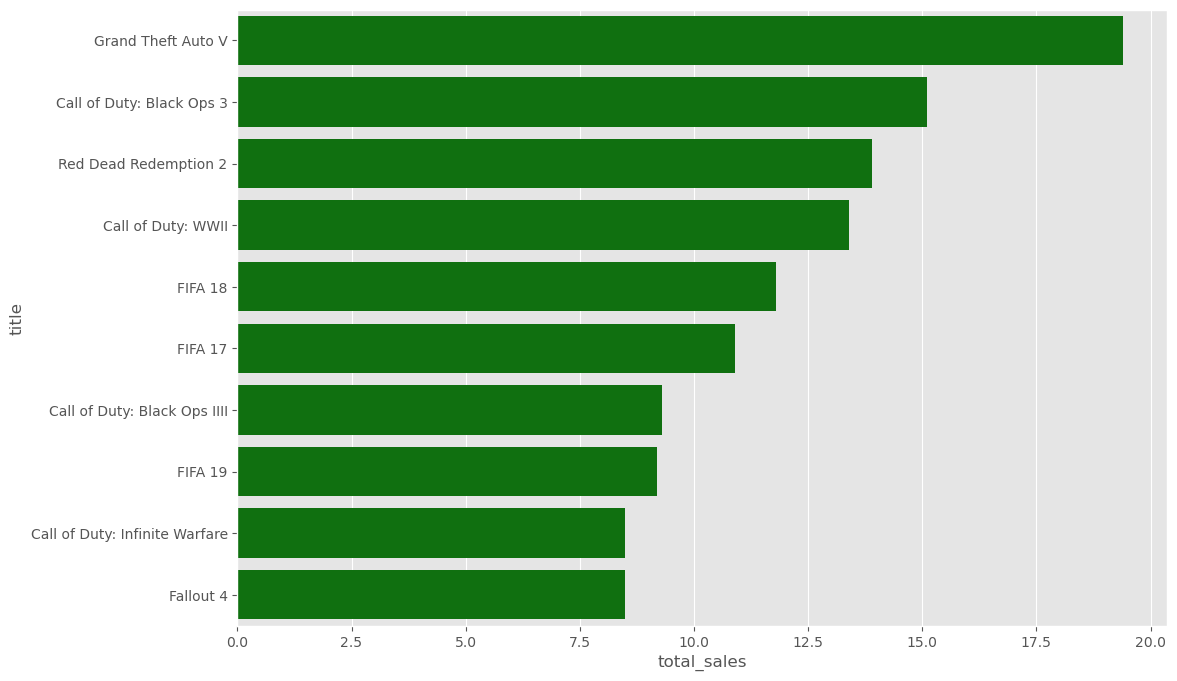

In [487]:
df1 = df[df['console'] == 'PS4']

agg_sum = df1.groupby('title')['total_sales'].sum().reset_index()

df_top5 = agg_sum.nlargest(10, 'total_sales')

sns.barplot(x='total_sales', y='title', data=df_top5, color = 'green')

## I'm keen to look for some consoles that specialize a particular genre, preferrably Playstation

In [509]:
#dfcons = df.groupby(['console'])['title'].count().reset_index()
#dfcons = df.groupby(['console','genre'])['title'].count().reset_index()
#sdfcons = dfcons.sort_values( by = 'title', ascending=False)
#sdfcons

pivot_df = df.pivot_table(index='console', columns='genre', values='title', aggfunc='count')
fpivot_df = pivot_df.loc[['PS','PS2', 'PS3', 'PS4','PS5']]
fpivot_df

genre,Action,Action-Adventure,Adventure,Board Game,Education,Fighting,MMO,Misc,Music,Party,Platform,Puzzle,Racing,Role-Playing,Sandbox,Shooter,Simulation,Sports,Strategy,Visual Novel
console,,,,,,,,,,,,,,,,,,,,
PS,233.0,1.0,241.0,NaN,NaN,180.0,NaN,436.0,NaN,2.0,97.0,134.0,231.0,212.0,NaN,173.0,152.0,396.0,218.0,1.0
PS2,443.0,2.0,521.0,NaN,1.0,212.0,1.0,493.0,NaN,2.0,138.0,52.0,327.0,281.0,NaN,245.0,165.0,561.0,118.0,3.0
PS3,364.0,41.0,107.0,NaN,NaN,92.0,4.0,371.0,16.0,1.0,61.0,16.0,117.0,149.0,NaN,214.0,45.0,244.0,39.0,24.0
PS4,531.0,269.0,289.0,1.0,1.0,124.0,17.0,152.0,45.0,19.0,153.0,85.0,142.0,371.0,2.0,262.0,100.0,159.0,90.0,66.0
PS5,69.0,129.0,88.0,1.0,NaN,23.0,3.0,5.0,5.0,2.0,42.0,14.0,42.0,90.0,NaN,66.0,35.0,15.0,17.0,2.0


 ### The above table shows that each version of Playstation series focus on the ff genre of games:

PS: Sports

PS2: Sports

PS3: Action and Misc.

PS4: Action

PS5: Action and Adventure

## Let's also wanted to try to plot the trend of sales year by year of each genre.

<Axes: xlabel='Year_release', ylabel='total_sales'>

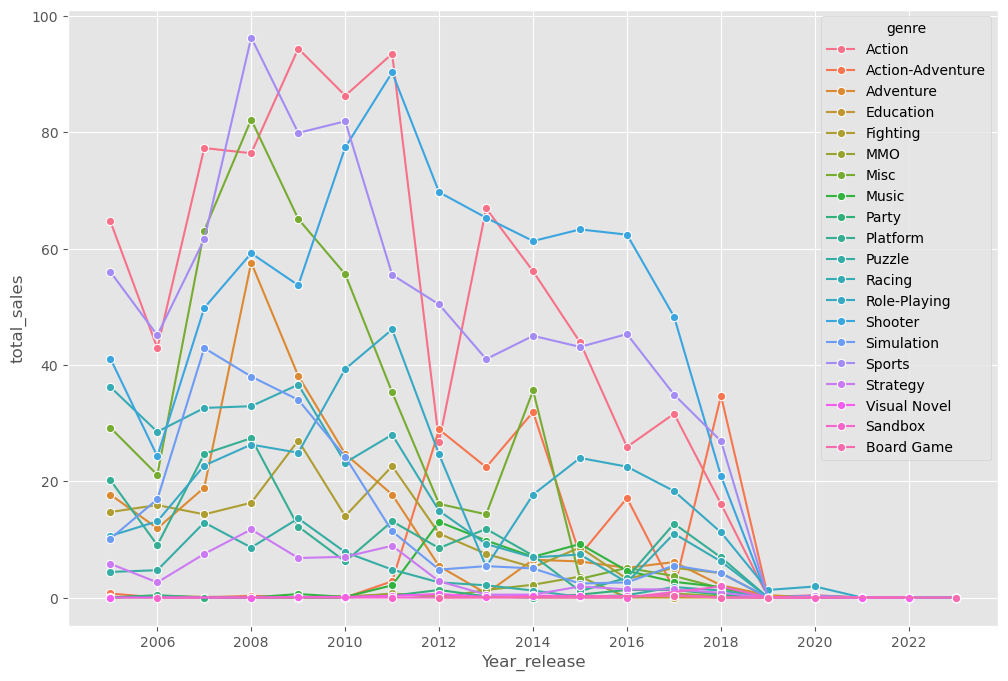

In [331]:
sns.lineplot(x='Year_release', y='total_sales', hue = 'genre', data = dfg_10y, marker = 'o')

## I wanted to look into different regions, find out their top 10 most purchased games. First up is Japan.

<Axes: xlabel='jp_sales', ylabel='title'>

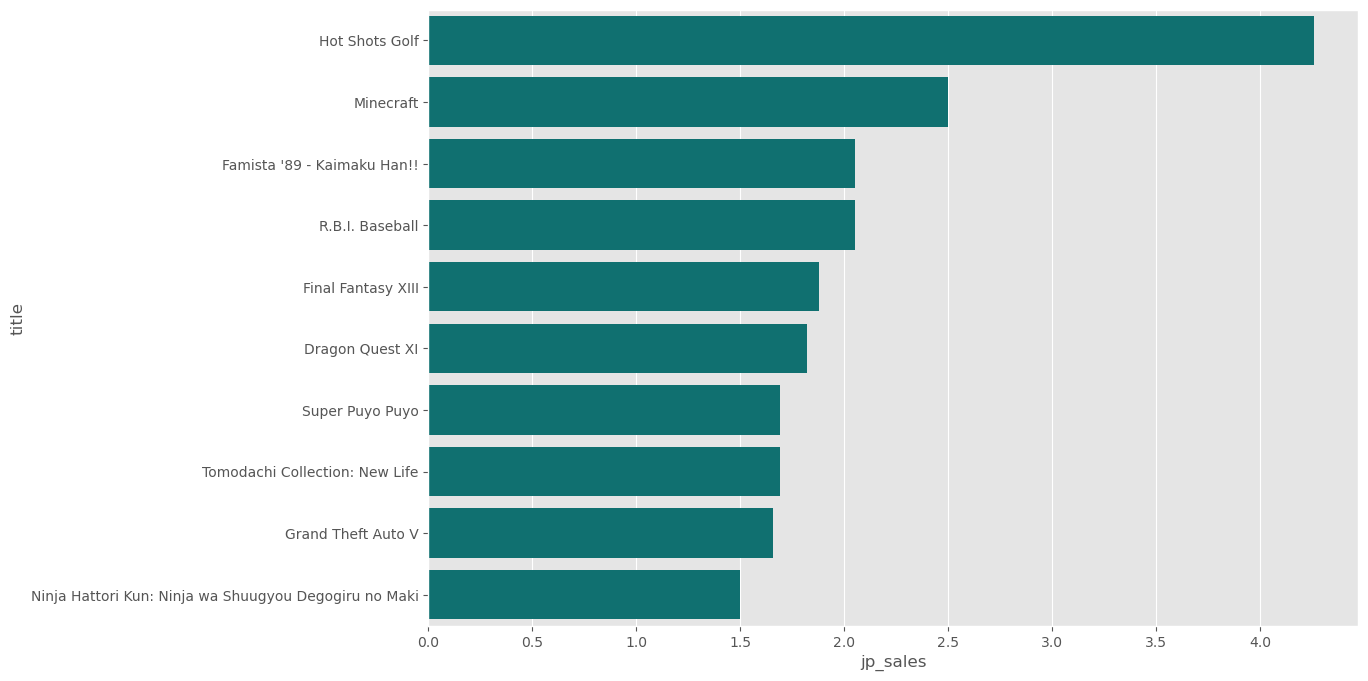

In [463]:
agg_jp = df.groupby('title')['jp_sales'].sum().reset_index()

df_top10jp = agg_jp.nlargest(10, 'jp_sales')

sns.barplot(x='jp_sales', y='title', data=df_top10jp, color = 'teal')

## Next is EMEA (PAL).

<Axes: xlabel='pal_sales', ylabel='title'>

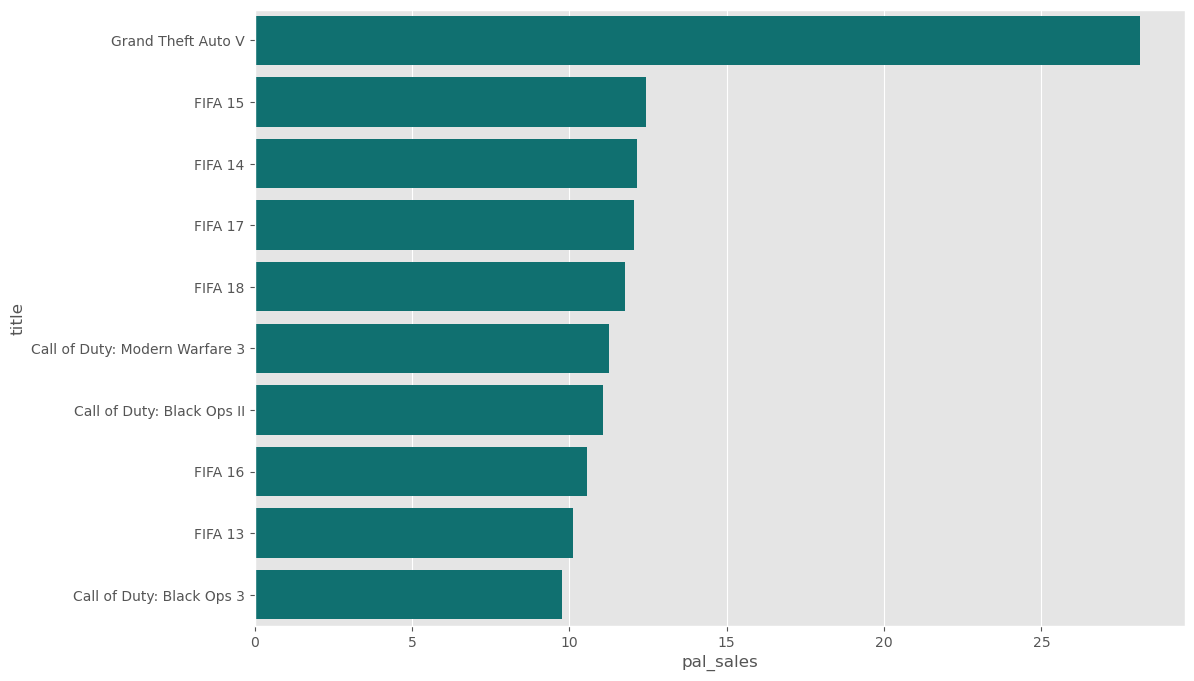

In [465]:
agg_pal = df.groupby('title')['pal_sales'].sum().reset_index()

df_top10pal = agg_pal.nlargest(10, 'pal_sales')

sns.barplot(x='pal_sales', y='title', data=df_top10pal, color = 'teal')

## And then, North America

<Axes: xlabel='na_sales', ylabel='title'>

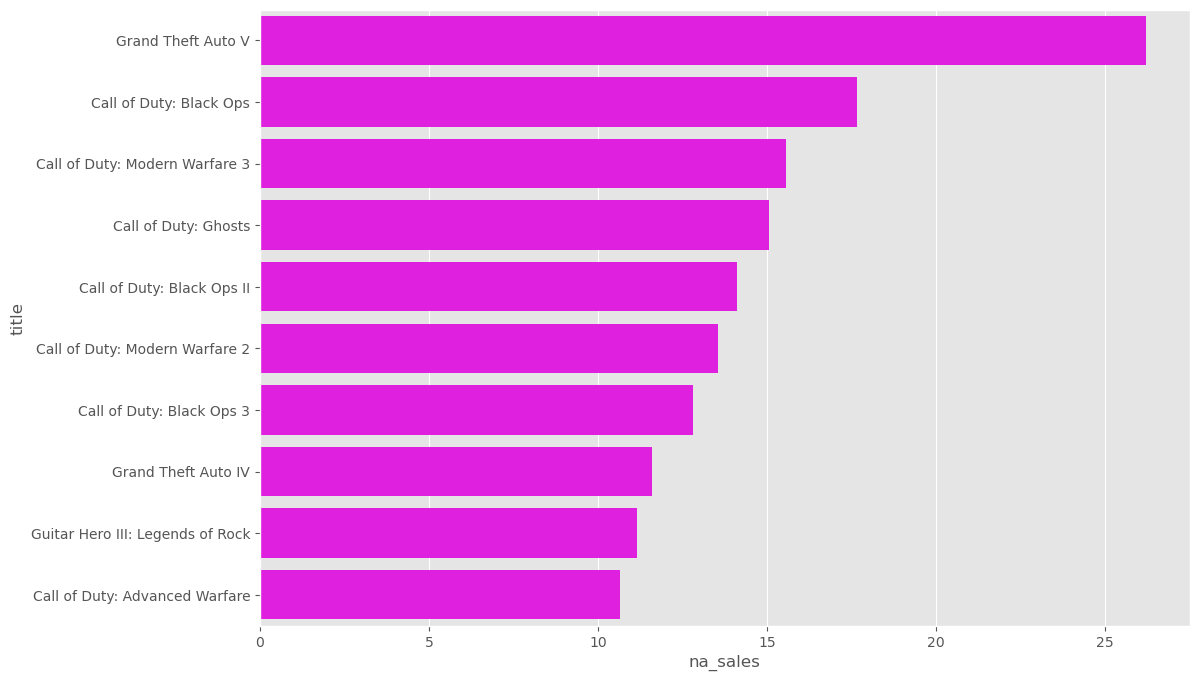

In [528]:
agg_na = df.groupby('title')['na_sales'].sum().reset_index()

df_top10na = agg_na.nlargest(10, 'na_sales')

sns.barplot(x='na_sales', y='title', data=df_top10na, color = 'magenta')

## And finally, the rest of the regions

<Axes: xlabel='other_sales', ylabel='title'>

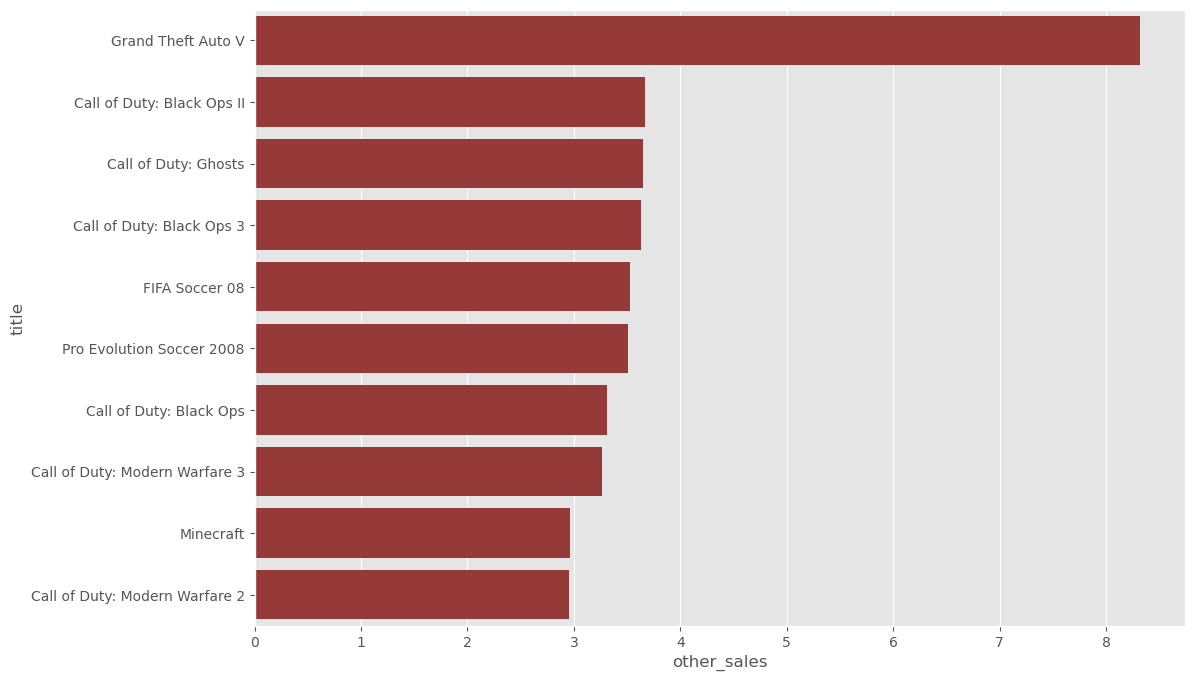

In [526]:
agg_o = df.groupby('title')['other_sales'].sum().reset_index()

df_top10o = agg_o.nlargest(10, 'other_sales')

sns.barplot(x='other_sales', y='title', data=df_top10o, color = 'brown')

## To give a conclusion to this brief EDA. Here are my findings:

1. To answer the first question, critic score does not correlate with the volume of sales for a game.
2. There's a downward trend recently for the amount of sales for games, peaked at 2008 then fell down.
    - I think few of the reasons for this is the rise of mobile gaming, since people started to use smartphone this late 2000s.
    - Next is that nowadays, games were bought via online platforms such as Steam. Where a game can be played for free, however, if you wanted
        to have an advantage to the game, you would need to purchase some items or credits to their online store.
    - Another reason is the affordability of console games, console games were supposed to be cheap back then, however, as time goes by, all of the
        prices have gone up, and this leads to people prioritizing games less.

3. To answer the 3rd question, I first plotted the most popular games each region and here are my observations:
    - North America prefers games that involves shooting, such as Call of Duty and Grand Theft Auto series.
    - EMEA prefers games related to sports, especially FIFA series. Since most people are into football, unlike USA who were more into
        basketball and American Football.
    - Japan has a diverse preference in terms of games. Popular sports in Japan are Golf, and Baseball. And they also into creative games such as
        Minecraft.
    - Lastly, the rest of the regions are into Shooting games as well. No wonder Grand Theft Auto and Call of Duty series are the top selling games of all time.
        Wherein North America and rest of the regions are the top contributors in terms of sales.